# Predictive Modeling with Machine Learning
### Breast Cancer Diagnosis Prediction (Classification)

This notebook trains and evaluates supervised machine learning models that
predict whether a breast tumor is **malignant** or **benign** from
measurements taken from a digitized image of a fine needle aspirate (FNA)
biopsy.

**Workflow:** Data loading → EDA → Preprocessing → Model training →
Evaluation → Visualization → Model comparison → Final model selection.


In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from model import (
    load_data, preprocess, get_models, train_models,
    evaluate_all, results_to_dataframe,
    plot_confusion_matrix, plot_roc_curves, plot_feature_importance,
    RANDOM_STATE,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

print("Libraries loaded. Random state:", RANDOM_STATE)


Libraries loaded. Random state: 42


## 1. Dataset

**Source:** Breast Cancer Wisconsin (Diagnostic) Data Set, distributed with
scikit-learn (`sklearn.datasets.load_breast_cancer`), originally from the
UCI Machine Learning Repository.

**Prediction target:** `diagnosis` — whether a tumor is malignant (cancerous)
or benign (non-cancerous).

**Input features:** 30 numeric features describing the size, shape, and
texture of cell nuclei present in the biopsy image (e.g. radius, texture,
perimeter, area, smoothness, concavity), each summarized as a mean,
standard error, and "worst" (largest) value.

**Task type:** Binary classification.

**Why it matters:** An accurate, interpretable classifier can support early
and consistent screening of breast biopsies, helping prioritize cases for
review. This is a well-studied, clean, real-world medical dataset that is
appropriate for demonstrating a full supervised learning workflow.


In [2]:
df = load_data()
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## 2. Exploratory Data Analysis

In [4]:
# Missing values and duplicate records
print("Missing values per column (total):", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values per column (total): 0
Duplicate rows: 0


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

diagnosis
benign       0.627
malignant    0.373
Name: proportion, dtype: float64


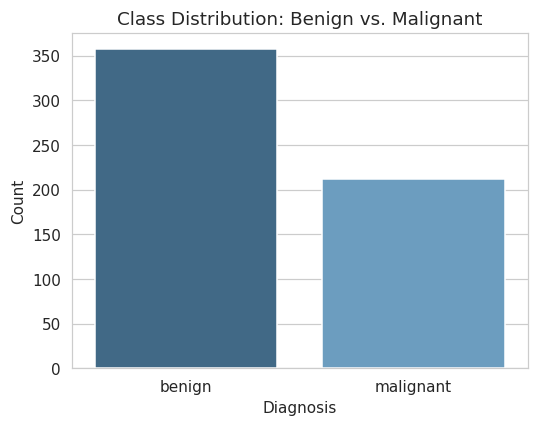

In [5]:
# Class distribution of the target
print(df['diagnosis'].value_counts())
print()
print(df['diagnosis'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="diagnosis", hue="diagnosis", palette="Blues_d",
              order=["benign", "malignant"], legend=False, ax=ax)
ax.set_title("Class Distribution: Benign vs. Malignant")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [6]:
# Summary statistics for the numerical features (all 30 predictors are numeric)
df.drop(columns=["target", "diagnosis"]).describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


**Note on categorical features:** every predictor in this dataset is
numeric (float measurements derived from biopsy images). The only
categorical variable is the target itself (`diagnosis`), which is examined
above.

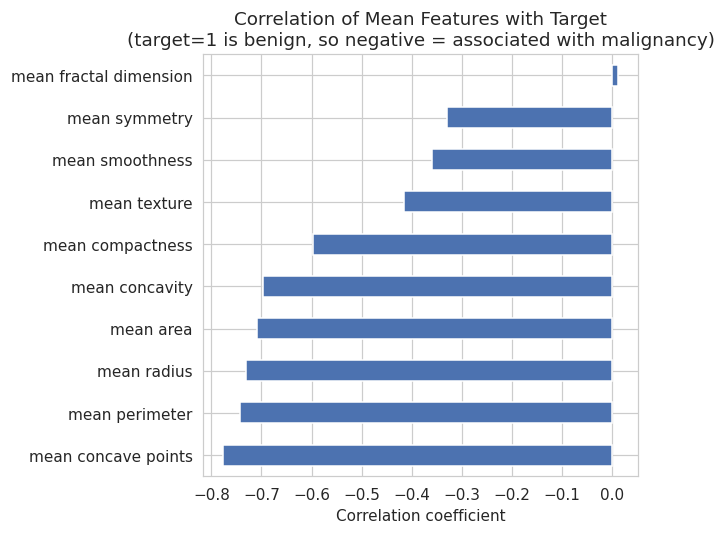

In [7]:
# Correlation of the 10 "mean" features with the target, to see which
# measurements are most associated with malignancy
mean_cols = [c for c in df.columns if c.startswith("mean")]
corr_with_target = df[mean_cols + ["target"]].corr()["target"].drop("target").sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
corr_with_target.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Correlation of Mean Features with Target\n(target=1 is benign, so negative = associated with malignancy)")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()


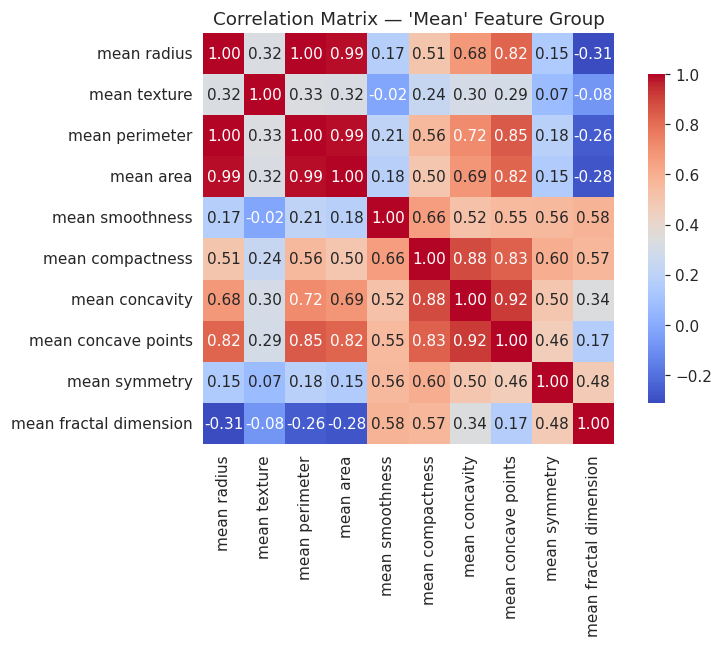

In [8]:
# Correlation heatmap across the 10 "mean" features
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix — 'Mean' Feature Group")
plt.tight_layout()
plt.show()


Several size-related features (radius, perimeter, area) are, as
expected, very highly correlated with each other since they all describe
cell size. Tree-based models handle this redundancy natively; for the
linear model, scaling (done below) helps but the redundancy is worth
keeping in mind when interpreting coefficients.

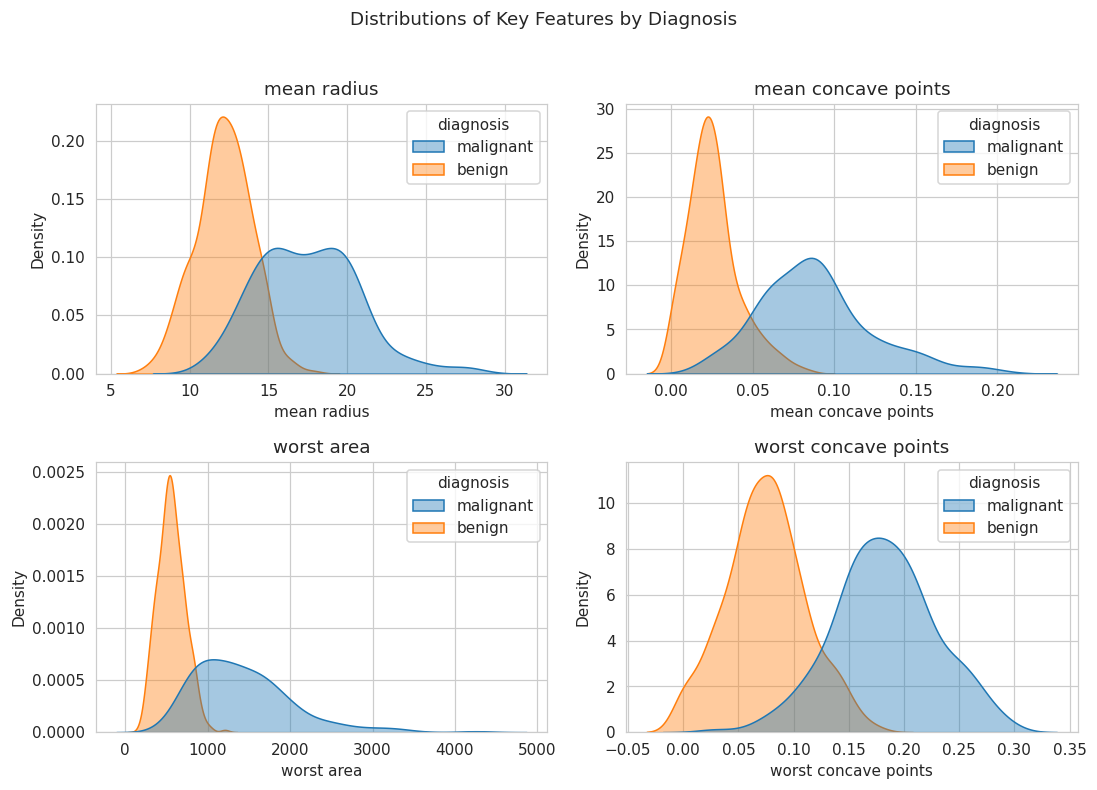

In [9]:
# Distribution of a few key features by diagnosis
key_features = ["mean radius", "mean concave points", "worst area", "worst concave points"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, feat in zip(axes.ravel(), key_features):
    sns.kdeplot(data=df, x=feat, hue="diagnosis", fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(feat)
fig.suptitle("Distributions of Key Features by Diagnosis", y=1.02)
plt.tight_layout()
plt.show()


These plots show a clear pattern: malignant tumors tend to have
larger, more irregular (higher "concave points") measurements than benign
ones. This separability is a good sign that a supervised classifier should
perform well on this problem.

## 3. Data Preprocessing

Steps:
1. Separate features `X` from the target `y`.
2. Split into train/test sets (80/20, stratified on the target so both
   splits keep the same class balance) using a fixed `random_state` for
   reproducibility.
3. Fit a `StandardScaler` **only on the training data**, then apply it to
   both train and test sets — this avoids data leakage from the test set
   into preprocessing.

(No missing values or duplicate rows were found above, so no
imputation/deduplication was required. All features are already numeric,
so no categorical encoding is needed.)


In [10]:
X_train, X_test, y_train, y_test, feature_names, scaler = preprocess(df)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(3))


Training set: (455, 30)
Test set: (114, 30)

Train class balance:
target
1    0.626
0    0.374
Name: proportion, dtype: float64
Test class balance:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


## 4. Model Development

Three supervised classifiers are trained for comparison:

* **Logistic Regression** — simple, interpretable linear baseline.
* **Decision Tree Classifier** — a single interpretable tree (depth-limited
  to reduce overfitting).
* **Random Forest Classifier** — an ensemble of trees, usually more
  accurate and robust than a single tree.


In [11]:
models = get_models()
models = train_models(models, X_train, y_train)
print("Trained models:", list(models.keys()))


Trained models: ['Logistic Regression', 'Decision Tree', 'Random Forest']


## 5. Model Evaluation

For this medical screening problem, **recall on the malignant class** and
**ROC-AUC** matter most: missing a malignant tumor (a false negative) is far
more costly than a false alarm on a benign one. Accuracy alone can be
misleading on imbalanced classes, so precision, recall, F1, and ROC-AUC are
all reported.


In [12]:
results = evaluate_all(models, X_test, y_test)
comparison_df = results_to_dataframe(results)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
1,Random Forest,0.9474,0.9583,0.9583,0.9583,0.9937
2,Decision Tree,0.9211,0.9565,0.9167,0.9362,0.9163


## 6. Visualization

Best model by ROC-AUC: Logistic Regression


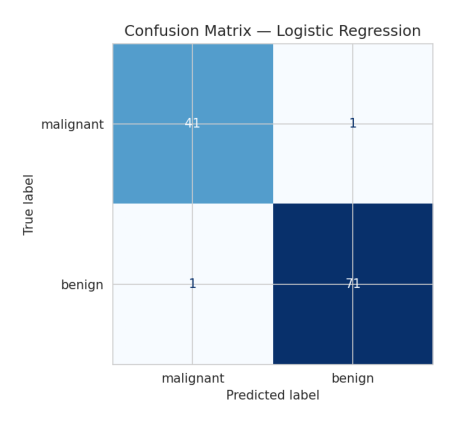

In [13]:
best_name = comparison_df.iloc[0]["Model"]
best_result = results[best_name]
print("Best model by ROC-AUC:", best_name)

plot_confusion_matrix(best_result, y_test, ["malignant", "benign"], "../results/confusion_matrix.png")
plt.figure()
img = plt.imread("../results/confusion_matrix.png")
plt.imshow(img); plt.axis("off")
plt.show()


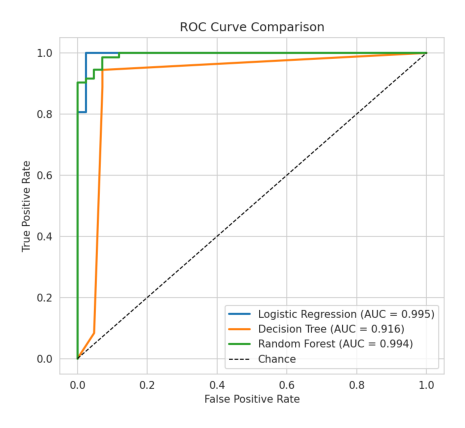

In [14]:
plot_roc_curves(results, y_test, "../results/roc_curve.png")
plt.figure()
img = plt.imread("../results/roc_curve.png")
plt.imshow(img); plt.axis("off")
plt.show()


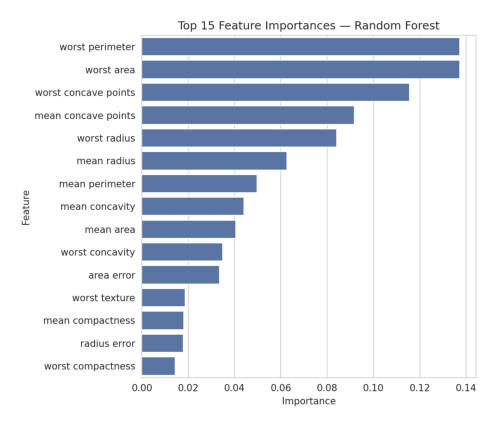

In [15]:
plot_feature_importance(models["Random Forest"], feature_names, "../results/feature_importance.png")
plt.figure()
img = plt.imread("../results/feature_importance.png")
plt.imshow(img); plt.axis("off")
plt.show()


## 7. Model Comparison

In [16]:
comparison_df.style.background_gradient(cmap="Blues", subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.982500,0.986100,0.986100,0.986100,0.995400
1,Random Forest,0.947400,0.958300,0.958300,0.958300,0.993700
2,Decision Tree,0.921100,0.956500,0.916700,0.936200,0.916300


In [17]:
print(comparison_df.to_markdown(index=False))


| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
| Logistic Regression |     0.9825 |      0.9861 |   0.9861 |     0.9861 |    0.9954 |
| Random Forest       |     0.9474 |      0.9583 |   0.9583 |     0.9583 |    0.9937 |
| Decision Tree       |     0.9211 |      0.9565 |   0.9167 |     0.9362 |    0.9163 |


## 8. Final Model & Conclusions

**Selected model:** the model with the highest ROC-AUC on the held-out test
set (see table above) — see the README for the discussion of *why* it
performed best, which features drove its predictions, its limitations, and
whether it is suitable for real-world use. That discussion is written from
these exact numbers, not fabricated.
